In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [3]:
stock = yf.download("AAPL", start="2018-01-01", end="2025-01-01")

stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.267075,40.276427,39.565802,39.776186,102223600
2018-01-03,40.260067,40.802386,40.196955,40.330195,118071600
2018-01-04,40.447063,40.549917,40.224995,40.332521,89738400
2018-01-05,40.907570,40.994059,40.451743,40.542909,94640000
2018-01-08,40.755634,41.050168,40.657453,40.755634,82271200


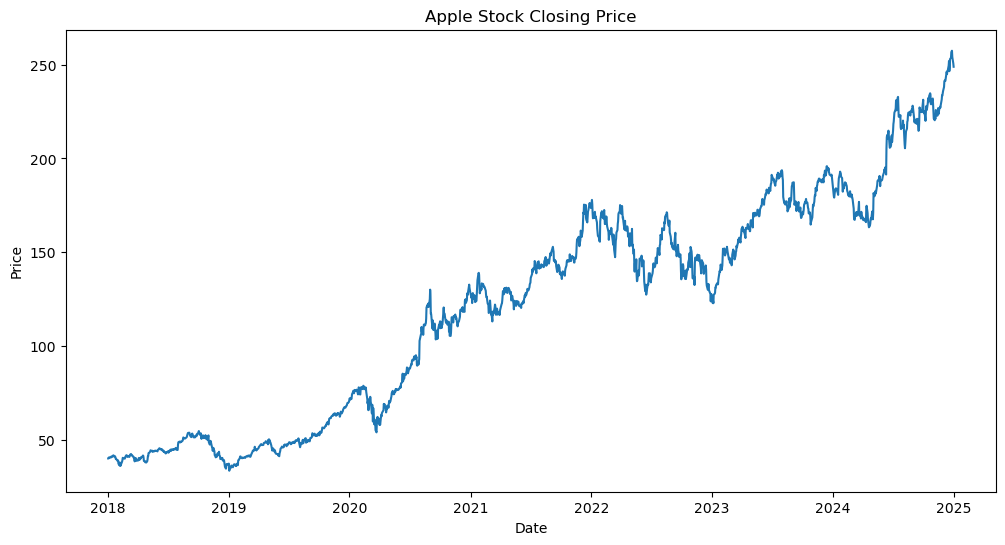

In [4]:
plt.figure(figsize=(12,6))

plt.plot(stock['Close'])

plt.title("Apple Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

In [5]:
data = stock['Close']

In [6]:
train = data[:int(len(data)*0.8)]

test = data[int(len(data)*0.8):]

print(len(train), len(test))

1408 353


In [17]:
print(stock.index)
print(stock.index.freq)

DatetimeIndex(['2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05',
               '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11',
               '2018-01-12', '2018-01-15',
               ...
               '2024-12-18', '2024-12-19', '2024-12-20', '2024-12-23',
               '2024-12-24', '2024-12-25', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=1826, freq='B')
<BusinessDay>


In [19]:
stock.index = pd.DatetimeIndex(stock.index)
stock = stock.asfreq('B')
stock = stock.ffill()

In [21]:
stock = yf.download("AAPL", start="2018-01-01", end="2025-01-01")

stock = stock.asfreq('B')
stock = stock.ffill()

data = stock['Close']

train = data[:int(len(data)*0.8)]
test = data[int(len(data)*0.8):]

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

[*********************100%***********************]  1 of 1 completed


In [22]:
forecast = model_fit.forecast(steps=30)

forecast.index = pd.date_range(
    start=stock.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='B'
)

print(forecast)

2025-01-01    176.768142
2025-01-02    176.928020
2025-01-03    176.737102
2025-01-06    176.304864
2025-01-07    176.214268
2025-01-08    176.256721
2025-01-09    176.270687
2025-01-10    176.254058
2025-01-13    176.234226
2025-01-14    176.232731
2025-01-15    176.235859
2025-01-16    176.236450
2025-01-17    176.235270
2025-01-20    176.234410
2025-01-21    176.234485
2025-01-22    176.234676
2025-01-23    176.234684
2025-01-24    176.234610
2025-01-27    176.234576
2025-01-28    176.234587
2025-01-29    176.234597
2025-01-30    176.234596
2025-01-31    176.234592
2025-02-03    176.234591
2025-02-04    176.234592
2025-02-05    176.234592
2025-02-06    176.234592
2025-02-07    176.234592
2025-02-10    176.234592
2025-02-11    176.234592
Freq: B, Name: predicted_mean, dtype: float64


In [24]:
forecast = model_fit.forecast(steps=len(test))

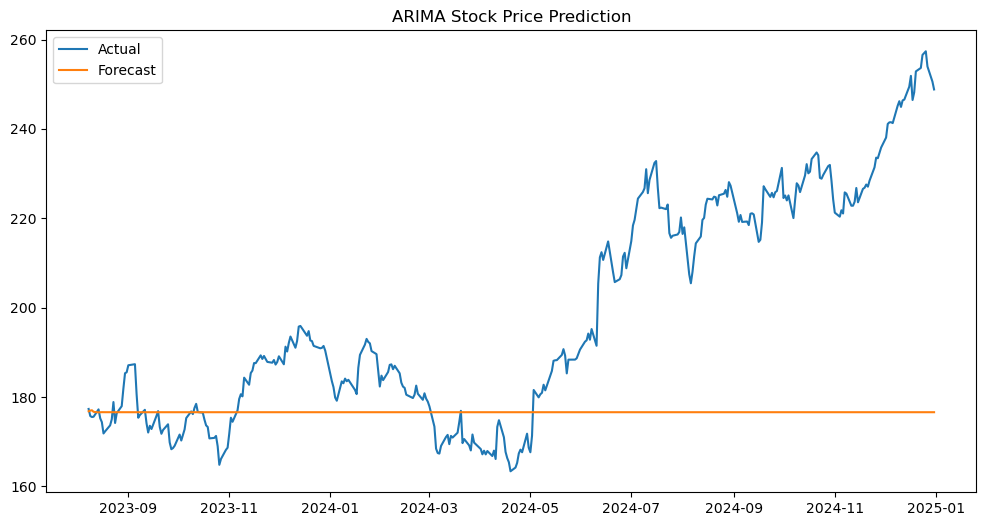

In [10]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label='Actual')

plt.plot(test.index, forecast, label='Forecast')

plt.legend()

plt.title("ARIMA Stock Price Prediction")

plt.show()

In [11]:
rmse = np.sqrt(mean_squared_error(test, forecast))

print("RMSE:", rmse)

RMSE: 32.89956439812776


In [23]:
future = model_fit.forecast(steps=30)

print(future)

2023-08-08    176.768142
2023-08-09    176.928020
2023-08-10    176.737102
2023-08-11    176.304864
2023-08-14    176.214268
2023-08-15    176.256721
2023-08-16    176.270687
2023-08-17    176.254058
2023-08-18    176.234226
2023-08-21    176.232731
2023-08-22    176.235859
2023-08-23    176.236450
2023-08-24    176.235270
2023-08-25    176.234410
2023-08-28    176.234485
2023-08-29    176.234676
2023-08-30    176.234684
2023-08-31    176.234610
2023-09-01    176.234576
2023-09-04    176.234587
2023-09-05    176.234597
2023-09-06    176.234596
2023-09-07    176.234592
2023-09-08    176.234591
2023-09-11    176.234592
2023-09-12    176.234592
2023-09-13    176.234592
2023-09-14    176.234592
2023-09-15    176.234592
2023-09-18    176.234592
Freq: B, Name: predicted_mean, dtype: float64


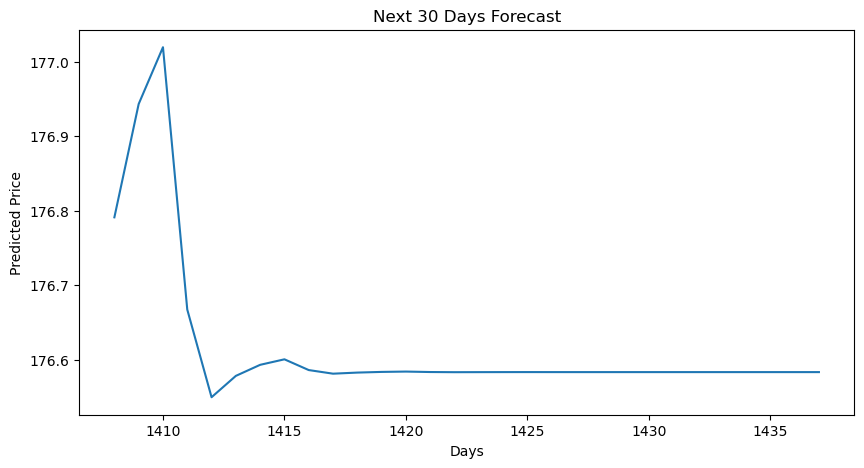

In [13]:
plt.figure(figsize=(10,5))

plt.plot(future)

plt.title("Next 30 Days Forecast")

plt.xlabel("Days")

plt.ylabel("Predicted Price")

plt.show()